In [1]:
install.packages(c("stats", "e1071", "rpart", "randomForest", "caret"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘stats’ is a base package, and should not be updated”
also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘proxy’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




# Linear Regression

In [2]:
# Synthetic dataset
set.seed(123)
x <- rnorm(100)
y <- 2 * x + rnorm(100)

# Fit model
model <- lm(y ~ x)

# Summary & prediction
summary(model)
pred <- predict(model, newdata = data.frame(x = c(1, 2)))
print(pred)


Call:
lm(formula = y ~ x)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.9073 -0.6835 -0.0875  0.5806  3.2904 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.10280    0.09755  -1.054    0.295    
x            1.94753    0.10688  18.222   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9707 on 98 degrees of freedom
Multiple R-squared:  0.7721,	Adjusted R-squared:  0.7698 
F-statistic:   332 on 1 and 98 DF,  p-value: < 2.2e-16


       1        2 
1.844725 3.792254 


# Logistic Regression

In [3]:
# Synthetic dataset
set.seed(123)
x <- rnorm(100)
y <- ifelse(2 * x + rnorm(100) > 0, 1, 0)

# Fit model
model <- glm(y ~ x, family = binomial())

# Predict probabilities
pred <- predict(model, newdata = data.frame(x = c(1, -1)), type = "response")
print(round(pred, 2))

   1    2 
0.96 0.06 


# KMeans

In [4]:
# Synthetic dataset
set.seed(123)
data <- rbind(matrix(rnorm(100, mean = 0), ncol = 2),
              matrix(rnorm(100, mean = 3), ncol = 2))

# Fit model
kmeans_model <- kmeans(data, centers = 2)

# Show cluster assignments
print(kmeans_model$cluster)

  [1] 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 [75] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2


# CART (Classification and Regression Tree)

1 
B 
Levels: A B


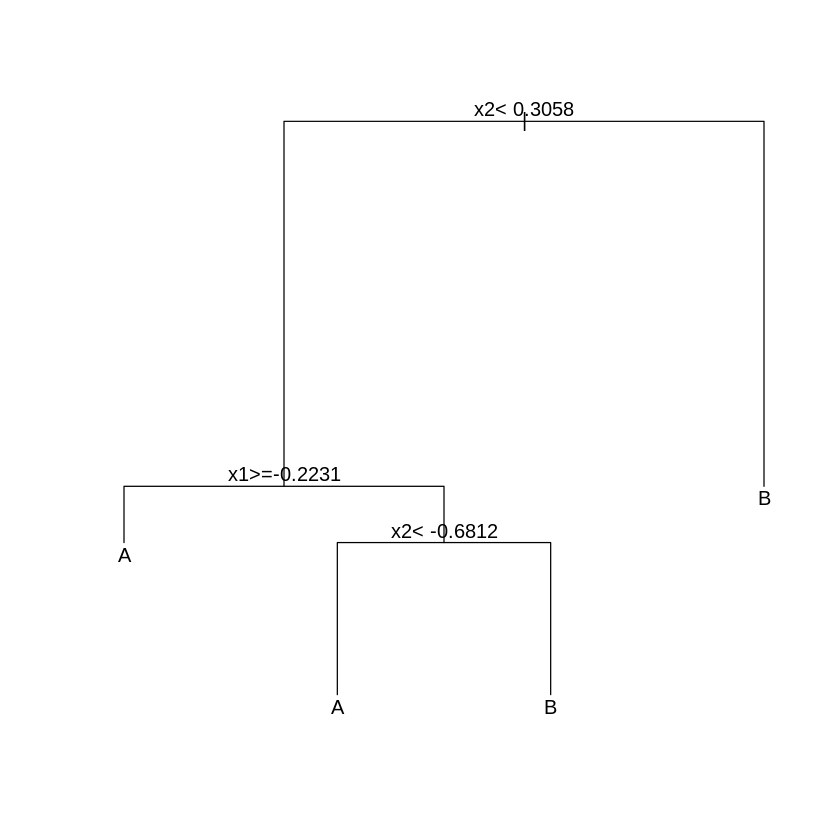

In [5]:
# Synthetic dataset
set.seed(123)
x1 <- rnorm(100)
x2 <- rnorm(100)
y <- factor(ifelse(0.5 * x1 - 0.5 * x2 > 0, "A", "B"))
df <- data.frame(x1, x2, y)

# Fit model
library(rpart)
tree_model <- rpart(y ~ ., data = df, method = "class")

# Plot and predict
plot(tree_model); text(tree_model)
pred <- predict(tree_model, newdata = data.frame(x1 = 1, x2 = 1), type = "class")
print(pred)

# Random Forest

In [6]:
# Synthetic dataset (same as above)
df <- data.frame(x1, x2, y)

# Fit model
library(randomForest)
rf_model <- randomForest(y ~ ., data = df)

# Predict
pred <- predict(rf_model, newdata = data.frame(x1 = 1, x2 = 1))
print(pred)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.



1 
B 
Levels: A B


# Naive Bayes

In [7]:
# Synthetic dataset (same as above)
df <- data.frame(x1, x2, y)

# Fit model
library(e1071)
nb_model <- naiveBayes(y ~ ., data = df)

# Predict
pred <- predict(nb_model, newdata = data.frame(x1 = 1, x2 = 1))
print(pred)

[1] B
Levels: A B


# Support Vector Machine


In [8]:
# Synthetic dataset (same as above)
df <- data.frame(x1, x2, y)

# Fit model
library(e1071)
svm_model <- svm(y ~ ., data = df)

# Predict
pred <- predict(svm_model, newdata = data.frame(x1 = 1, x2 = 1))
print(pred)

1 
B 
Levels: A B




---

## 🔢 1. **Linear Regression**

### 🧮 Mathematical Foundation:
- Goal: Minimize the **sum of squared errors (SSE)** between actual values $ y_i $ and predicted values $ \hat{y}_i $.
- The linear equation is:

$$
\hat{y}_i = w_0 + w_1 x_{i1} + w_2 x_{i2} + \cdots + w_p x_{ip}
$$

Where:
- $ \hat{y}_i $: Predicted output
- $ x_{ij} $: Input features
- $ w_j $: Coefficients/weights learned from data

The error function (cost function) is:

$$
\text{SSE} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

This is minimized using **Ordinary Least Squares (OLS)** method, which solves analytically:

$$
\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

Where:
- $ \mathbf{X} $: Matrix of input features (including intercept)
- $ \mathbf{y} $: Vector of target values
- $ \mathbf{w} $: Vector of weights

### ⚙️ How It Works:
- Finds the line (or hyperplane in higher dimensions) that best fits the data by minimizing the vertical distance (squared error) between observed and predicted points.
- Assumes a linear relationship between inputs and output.

---

## 📊 2. **Logistic Regression**

### 🧮 Mathematical Foundation:
- Used for binary classification.
- Models the **probability** that a given input belongs to class 1.

$$
P(y=1 | \mathbf{x}) = \frac{1}{1 + e^{-(w_0 + w_1x_1 + \cdots + w_px_p)}}
$$

This is the **sigmoid function** applied to a linear combination of features.

- Cost function is based on **log loss** (cross-entropy):

$$
\text{Cost} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i)\log(1 - \hat{p}_i) \right]
$$

Where $ \hat{p}_i = P(y_i = 1 | \mathbf{x}_i) $

- Optimization uses **Iteratively Reweighted Least Squares (IRLS)** or **gradient descent**.

### ⚙️ How It Works:
- Learns coefficients $ w_j $ such that the logistic function outputs high probability for one class and low for the other.
- Output is interpreted as a **probability** of belonging to a class, not just a class label.

---

## 🌐 3. **K-Means Clustering**

### 🧮 Mathematical Foundation:
- Objective: Partition data into $ k $ clusters such that within-cluster variance is minimized.

$$
\text{Minimize } \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

Where:
- $ C_i $: Cluster $ i $
- $ \mu_i $: Centroid (mean) of cluster $ i $

### ⚙️ How It Works:
1. Randomly initialize $ k $ centroids.
2. Assign each point to the nearest centroid (using Euclidean distance).
3. Recalculate centroids as mean of all points in the cluster.
4. Repeat steps 2–3 until convergence (no more reassignments).

- No global optimal solution guaranteed; sensitive to initial centroid positions.

---

## 🧬 4. **Hierarchical Clustering (Agglomerative)**

### 🧮 Mathematical Foundation:
- Starts with each point as its own cluster.
- Merges the two closest clusters iteratively using **linkage criteria**:

Common linkage methods:
- **Single Linkage**: $ d(C_1, C_2) = \min_{x \in C_1, y \in C_2} ||x - y|| $
- **Complete Linkage**: $ d(C_1, C_2) = \max_{x \in C_1, y \in C_2} ||x - y|| $
- **Average Linkage**: $ d(C_1, C_2) = \frac{1}{|C_1||C_2|} \sum_{x \in C_1, y \in C_2} ||x - y|| $
- **Ward’s Method**: Minimizes total within-cluster variance after merging.

### ⚙️ How It Works:
- Builds a **dendrogram** (tree of merges).
- Final clusters are determined by cutting the dendrogram at a desired height.

---

## 🌳 5. **Decision Tree (CART)**

### 🧮 Mathematical Foundation:
- Splits data recursively to reduce **impurity** at each node.
- For classification, impurity is measured using **Gini Index**:

$$
\text{Gini}(D) = 1 - \sum_{i=1}^{k} p_i^2
$$

Where $ p_i $: Proportion of class $ i $ in dataset $ D $

- For regression, impurity is measured using **variance reduction**:

$$
\text{Variance Reduction} = \text{Var}(D) - \sum_{j=1}^{m} \frac{|D_j|}{|D|} \text{Var}(D_j)
$$

### ⚙️ How It Works:
1. At each node, find the feature and threshold that most reduces impurity.
2. Split data accordingly.
3. Repeat recursively until stopping conditions (like max depth or min samples per leaf) are met.

---

## 🌲 6. **Random Forest**

### 🧮 Mathematical Foundation:
- Ensemble of decision trees trained on bootstrapped samples of data.
- Each tree learns different splits due to:
  - **Bootstrap sampling**: Samples drawn with replacement.
  - **Random feature selection**: Only a random subset of features considered at each split.

Final prediction:
- **Classification**: Majority vote or average probability across trees.
- **Regression**: Average of predictions from all trees.

### ⚙️ How It Works:
1. Generate multiple bootstrapped datasets.
2. Train a deep decision tree on each.
3. Combine predictions via averaging/voting.

Reduces overfitting and improves generalization.

---

## 🧪 7. **Naive Bayes**

### 🧮 Mathematical Foundation:
Based on **Bayes’ Theorem**:

$$
P(y | \mathbf{x}) = \frac{P(\mathbf{x} | y) P(y)}{P(\mathbf{x})}
$$

Assumes **feature independence**:

$$
P(\mathbf{x} | y) = \prod_{i=1}^{p} P(x_i | y)
$$

Different variants assume different distributions:
- **GaussianNB**: Features follow normal distribution.
- **MultinomialNB**: Counts (e.g., word frequencies).
- **BernoulliNB**: Binary features.

### ⚙️ How It Works:
1. For each class $ y $, compute $ P(y | \mathbf{x}) $ using above formula.
2. Class with highest posterior probability is selected as prediction.

Fast and efficient for high-dimensional sparse data.

---

## ⚙️ 8. **Support Vector Machine (SVM)**

### 🧮 Mathematical Foundation:
- Goal: Find **maximum-margin hyperplane** separating classes.

For linear SVM:

$$
\text{Maximize } \frac{2}{||\mathbf{w}||} \quad \text{subject to } y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1
$$

Where:
- $ \mathbf{w} $: Weight vector (normal to hyperplane)
- $ b $: Bias term
- $ y_i \in \{-1, 1\} $: Class labels

For non-linear problems, use **kernel trick**:

$$
K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)
$$

Common kernels:
- Linear: $ K(\mathbf{x}, \mathbf{x}') = \mathbf{x} \cdot \mathbf{x}' $
- Polynomial: $ K(\mathbf{x}, \mathbf{x}') = (\gamma \mathbf{x} \cdot \mathbf{x}' + c_0)^d $
- RBF (Radial Basis Function): $ K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma ||\mathbf{x} - \mathbf{x}'||^2) $

### ⚙️ How It Works:
1. Map data into higher-dimensional space using kernel.
2. Find optimal separating hyperplane.
3. Use support vectors (data points near boundary) to define decision surface.

Robust for complex decision boundaries but computationally expensive.

---

## ✅ Summary Table: Math Behind Each Algorithm

| Algorithm               | Core Math / Equation                                                                 | Key Concept                                             |
|------------------------|---------------------------------------------------------------------------------------|---------------------------------------------------------|
| Linear Regression       | $ \hat{y} = w_0 + w_1x_1 + \cdots + w_px_p $, minimize SSE                          | Best fit line                                           |
| Logistic Regression     | $ P(y=1|\mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x})}} $, log loss    | Probability modeling                                    |
| K-Means Clustering      | $ \sum ||x - \mu_i||^2 $, iterative centroid update                                 | Minimize within-cluster variance                        |
| Hierarchical Clustering | Distance-based merging using linkage functions                                       | Bottom-up clustering                                    |
| Decision Tree           | Gini index / variance reduction                                                      | Recursive splitting based on impurity                   |
| Random Forest           | Averaging over many trees built with bagging & feature randomness                    | Reduces variance, increases accuracy                    |
| Naive Bayes             | Bayes' theorem + feature independence assumption                                     | Probabilistic classification                            |
| Support Vector Machine  | Max-margin hyperplane + kernel trick                                                 | Nonlinear classification/regression via mapping         |

---



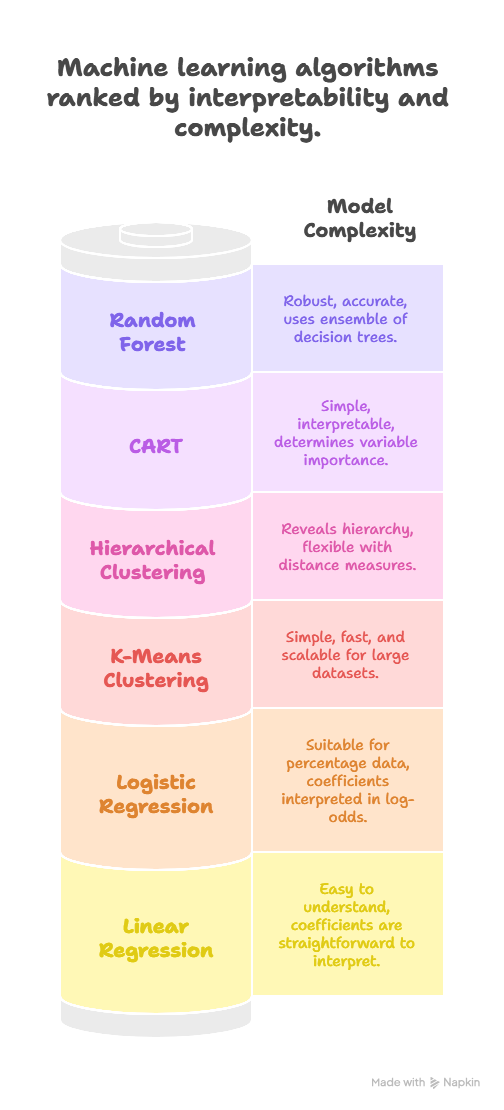